# バージョン情報
V1.1
アンサンブル
* **LightGBM**
* **XGBoost**


```
id : id
health_condition : 健康状態  (y)

==========================================

1  sleep_duration : 睡眠時間
2  heart_rate : 心拍数
3  bmi : BMI
4  calorie_expenditure :  カロリー消費量
5  step_count : ステップ数
6  exercise_duration : 運動時間
7  water_intake : 水分摂取量

9  stress_level : ストレスレベル
10 sleep_quality : 睡眠の質
11 physical_activity_level : 身体活動レベル


14 short_sleep_flag : 睡眠時間が6時間未満なら「1」、そうでない（空白も含む）なら「0」
15 exercise_strength : 運動の強度

==========================================
追加

16 healthy_score : 健康スコア
17 unhealthy_score : 不健康スコア
18 stress_per_sleep : ストレス係数:  ストレスレベル/睡眠時間

==========================================
削除

8  diet_type : 食事タイプ  #復活
13 gender : 性別
12 smoking_alcohol : 喫煙・飲酒



パラメータ v1.1

#### LGB

model_lgb_eval = lgb.LGBMClassifier(
    verbose=-1,
    class_weight='balanced',
    random_state=42,
    n_estimators=1000,
    learning_rate=0.013578512419982092,
    num_leaves=92,
    max_depth=9,
    min_child_samples=36,
    subsample=0.505217415288255,
    colsample_bytree=0.7581737202993579
)

### XGB

model_xgb_eval = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    enable_categorical=True,
    learning_rate=0.029880659828276236,
    max_depth=5,
    min_child_weight=9,
    subsample=0.9527064742344795,
    colsample_bytree=0.8672601416983036,
    n_estimators=1000,
    early_stopping_rounds=50
)


```

C:\Users\kyong\Predicting-Student-Health-Risk\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.170003


LightGBM 学習用Balanced Accuracy: 0.94998



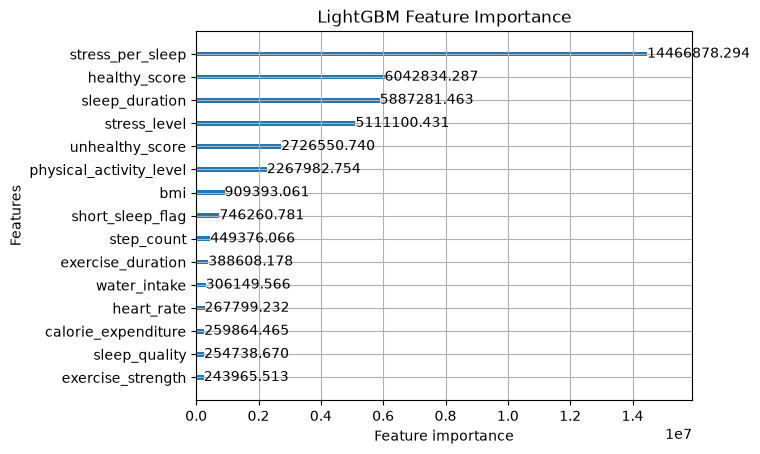



XGBoost 学習用Balanced Accuracy: 0.95045



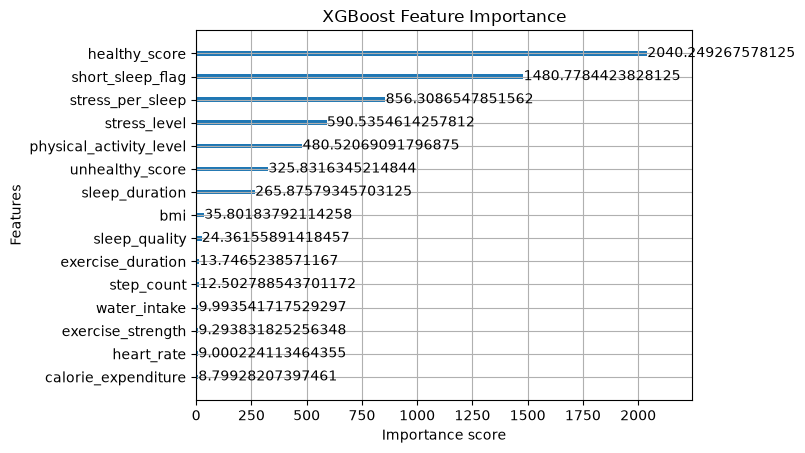



提出用ファイル 'submission.csv' を作成しました☆



In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

def df_Data_Cleansing(df):
    cat_cols = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().astype('category')
    #14
    df['short_sleep_flag'] = (df['sleep_duration'] < 6.0).astype(int)

    #15
    df["exercise_strength"] = df['calorie_expenditure'] / ((df['exercise_duration'] + 0.1) * df['bmi'])

    #16
    df['healthy_score'] = (
        df['sleep_duration'].between(7, 8).astype(int) +
        (df['bmi'] <= 19).astype(int) +
        (df['exercise_duration'] >= 40).astype(int) +
        (df['stress_level'] == 'low').astype(int) +
        (df['sleep_quality'] == 'good').astype(int) +
        (df['physical_activity_level'] == 'active').astype(int)
    )

    #17
    df['unhealthy_score'] = (
        df['sleep_duration'].between(5, 6).astype(int) +
        (df['bmi'] >= 27).astype(int) +
        (df['calorie_expenditure'] <= 1400).astype(int) +
        (df['step_count'] <= 5000).astype(int) +
        (df['exercise_duration'] <= 30).astype(int) +
        (df['stress_level'] == 'high').astype(int) +
        (df['sleep_quality'] == 'poor').astype(int) +
        df['physical_activity_level'].isin(['sedentary', 'moderate']).astype(int) +
        (df['smoking_alcohol'] == 'yes').astype(int)
    )

    #18
    stress_mapping = {'low': 1, 'medium': 2, 'high': 3}
    df['stress_level_num'] = df['stress_level'].map(stress_mapping).astype(float)
    df['stress_per_sleep'] = df['stress_level_num'] / df['sleep_duration']

    # 不要な特徴量をまとめて削除
    drop_cols = [
        'stress_level_num',
        'diet_type',
        'gender',
        'smoking_alcohol',
    ]
    df = df.drop(columns=drop_cols, errors='ignore')

    return df

#========
#読み込み
df = df_Data_Cleansing(pd.read_csv('data/train.csv',encoding="utf-8"))
df_test = df_Data_Cleansing(pd.read_csv('data/test.csv',encoding="utf-8"))

#特徴量(X)とターゲット(y)の分割
X = df.drop(['id', 'health_condition'], axis=1)
y = df['health_condition']

# stress_levelのラベルエンコーディング
le_stress = LabelEncoder()
X['stress_level'] = le_stress.fit_transform(X['stress_level'])
df_test['stress_level'] = le_stress.transform(df_test['stress_level'])

# 数値型の欠損値を中央値で補完（学習データの基準を使用）
NUMS = X.select_dtypes(include="float").columns.tolist() + X.select_dtypes(include="int").columns.tolist()
train_medians = X[NUMS].median()
X[NUMS] = X[NUMS].fillna(train_medians)
df_test[NUMS] = df_test[NUMS].fillna(train_medians)

#ターゲット(y)を数値に変換
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 学習データを8:2に分割
X_train, X_valid, y_train, y_valid = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_encoded)

# ========== LightGBM ==========
model_lgb_eval = lgb.LGBMClassifier(
    verbose=-1,
    class_weight='balanced',
    random_state=42,
    n_estimators=1000,
    learning_rate=0.013578512419982092,
    num_leaves=92,
    max_depth=9,
    min_child_samples=36,
    subsample=0.505217415288255,
    colsample_bytree=0.7581737202993579
)
model_lgb_eval.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

valid_preds_lgb = model_lgb_eval.predict(X_valid)
score_lgb = balanced_accuracy_score(y_valid, valid_preds_lgb)
print(f"""
=========================

LightGBM 学習用Balanced Accuracy: {score_lgb:.5f}

=========================""")

lgb.plot_importance(model_lgb_eval,
                    max_num_features=20,
                    importance_type='gain',
                    title='LightGBM Feature Importance')
plt.show()


model_lgb_full = lgb.LGBMClassifier(
    verbose=-1,
    class_weight='balanced',
    random_state=42,
    n_estimators=model_lgb_eval.best_iteration_,
    learning_rate=0.013578512419982092,
    num_leaves=92,
    max_depth=9,
    min_child_samples=36,
    subsample=0.505217415288255,
    colsample_bytree=0.7581737202993579
)
model_lgb_full.fit(X, y_encoded)

# ========== XGBoost ==========
model_xgb_eval = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    enable_categorical=True,
    learning_rate=0.029880659828276236,
    max_depth=5,
    min_child_weight=9,
    subsample=0.9527064742344795,
    colsample_bytree=0.8672601416983036,
    n_estimators=1000,
    early_stopping_rounds=50
)
model_xgb_eval.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

valid_preds_xgb = model_xgb_eval.predict(X_valid)
score_xgb = balanced_accuracy_score(y_valid, valid_preds_xgb)
print(f"""
=========================

XGBoost 学習用Balanced Accuracy: {score_xgb:.5f}

=========================""")

xgb.plot_importance(model_xgb_eval,
                    max_num_features=20,
                    importance_type='gain',
                    title='XGBoost Feature Importance')
plt.show()

model_xgb_full = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    enable_categorical=True,
    learning_rate=0.029880659828276236,
    max_depth=5,
    min_child_weight=9,
    subsample=0.9527064742344795,
    colsample_bytree=0.8672601416983036,
    n_estimators=model_xgb_eval.best_iteration
)
model_xgb_full.fit(X, y_encoded, sample_weight=sample_weights_full)

# ========== アンサンブル予測 ==========
X_test = df_test.drop(['id'], axis=1)

# 両方のモデルから予測確率を出力
preds_prob_lgb = model_lgb_full.predict_proba(X_test)
preds_prob_xgb = model_xgb_full.predict_proba(X_test)

# 確率を均等にブレンド
blend_prob = (preds_prob_lgb * 0.5) + (preds_prob_xgb * 0.5)

# 最も確率が高いクラスを選択
final_preds = np.argmax(blend_prob, axis=1)
submission_labels = le.inverse_transform(final_preds)

submission = pd.DataFrame({
    'id': df_test['id'],
    'health_condition': submission_labels
})

submission.to_csv('submission.csv', index=False)
X_test.head(100).to_csv("submit_x_x_x_x_x_x.csv", index=False)

print("""
=========================

提出用ファイル 'submission.csv' を作成しました☆

=========================""")


